# MFM FISHER

In [1]:
from simu_PSF_polarMFM import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from tqdm import tqdm

In [2]:
NPSF = 200
device='cuda'

In [3]:
N_photons=5000 # number of photons collected 
N=80 # discretization of the BFP
l_pixel=16 #pixel size in micrometer
NA=1.4 # numerical aperture
mag=100 # first magnification
lambd=617 # wavelength in nm
f_tube=200 # tube lens focal in mm
MAG=200/150 # second magnification

N_photons=torch.tensor(N_photons, device=device)
N=torch.tensor(N, device=device)
l_pixel=torch.tensor(l_pixel, device=device)
NA=torch.tensor(NA, device=device)
mag=torch.tensor(mag, device=device)
lambd=torch.tensor(lambd, device=device)
f_tube=torch.tensor(f_tube, device=device)
MAG=torch.tensor(MAG, device=device)

In [4]:
xp=torch.tensor([0. for i in range(NPSF)], device=device)
yp=torch.tensor([0. for i in range(NPSF)], device=device)
z=torch.tensor(1+np.random.rand(NPSF)*3, device=device)
d_=torch.tensor([-3. for i in range(NPSF)], device=device)
rho = torch.tensor([45 for k in range(NPSF)], device=device)
eta = torch.tensor([45 for k in range(NPSF)], device=device)
delta = torch.tensor([80 for k in range(NPSF)], device=device)
second_plane = torch.tensor([-0.3, 0, 0.3])
zernike_coefs_x = torch.zeros((3,15), device=device)
zernike_coefs_y = torch.zeros((3,15), device=device)
polar_projections = np.array([0, 45, 0])

In [5]:
J = np.array([[1,0],[0,1]])

In [6]:
SAF = False

In [7]:
if SAF:
    x, y, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, r_cut_saf, k, f_o, costh2 = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, SAF=SAF, device=device, J_dichroic=J)
else:
    costh2=None
    x, y, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, k, f_o = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, SAF=SAF, device=device, J_dichroic=J)

C:\Users\Amaury\Documents\GitHub\4polarMFM_these\simu_PSF_polarMFM.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  costh2 = costh2.astype(float)


In [8]:
phase_mask=torch.ones((N,N)) #np.exp(1j*phi)
phase_mask[x**2+y**2>r_cut**2]=1.

phase_mask = torch.stack([torch.ones((N,N), device=device), torch.tensor(phase_mask, device=device), torch.ones((N,N), device=device)])
zernike_base = generate_zernike_base(r_cut=r_cut, N=N, zernike_order=4, device=device)

C:\Users\Amaury\AppData\Local\Temp\ipykernel_19096\3780356185.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phase_mask = torch.stack([torch.ones((N,N), device=device), torch.tensor(phase_mask, device=device), torch.ones((N,N), device=device)])


In [9]:
u, v, Npadding = padding(r, r_cut, k, f_o, N=N, l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, 
              f_tube=f_tube, MAG=MAG, device=device)
print(Npadding)

tensor(74, device='cuda:0')


C:\Users\Amaury\anaconda3\envs\torch_new\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [10]:
th1 = pad(th1, Npadding)
phi = pad(phi, Npadding)
Ex0 = pad(Ex0, Npadding)
Ex1 = pad(Ex1, Npadding)
Ex2 = pad(Ex2, Npadding)
Ey0 = pad(Ey0, Npadding)
Ey1 = pad(Ey1, Npadding)
Ey2 = pad(Ey2, Npadding)
phase_mask = pad(phase_mask, Npadding)
zernike_base = pad(zernike_base, Npadding)
if SAF:
    costh2 = pad(costh2, Npadding)

In [11]:
phase_mask.shape

torch.Size([3, 154, 154])

In [12]:
M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                    Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                    phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, 
                    zernike_coefs_y=zernike_coefs_x, second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, 
                    BFP_version=False, SAF=SAF, costh2=costh2)

In [13]:
psf = PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons)

In [14]:
def fisher(M_matrix, RHO, ETA, DELTA, BACKGROUND):
    omega = 2*torch.pi*(1-torch.cos(DELTA))
    gamma = 1 - (3*omega)/(4*torch.pi) + omega**2/(8*torch.pi**2)
    
    dxx_eta = 2*gamma*(torch.cos(RHO)**2)*torch.sin(ETA)*torch.cos(ETA)
    dyy_eta = 2*gamma*(torch.sin(RHO)**2)*torch.sin(ETA)*torch.cos(ETA)
    dzz_eta = -2*gamma*torch.sin(ETA)*torch.cos(ETA)
    dxy_eta = 2*gamma*(torch.sin(RHO)*torch.cos(RHO))*torch.sin(ETA)*torch.cos(ETA)
    dxz_eta = gamma*torch.cos(RHO)*(torch.cos(ETA)**2-torch.sin(ETA)**2)
    dyz_eta = gamma*torch.sin(RHO)*(torch.cos(ETA)**2-torch.sin(ETA)**2)

    dxx_rho = -2*gamma*(torch.sin(ETA)**2)*torch.sin(RHO)*torch.cos(RHO)
    dyy_rho = 2*gamma*(torch.sin(ETA)**2)*torch.sin(RHO)*torch.cos(RHO)
    dzz_rho = 0*ETA
    dxy_rho = gamma*(torch.sin(ETA)**2)*(torch.cos(RHO)**2-torch.sin(RHO)**2)
    dxz_rho = -gamma*torch.cos(ETA)*torch.sin(ETA)*torch.sin(RHO)
    dyz_rho = gamma*torch.cos(ETA)*torch.sin(ETA)*torch.cos(RHO)

    dxx_gamma = (torch.sin(ETA)*torch.cos(RHO))**2 -1/3
    dyy_gamma = (torch.sin(ETA)*torch.sin(RHO))**2 -1/3
    dzz_gamma = (torch.cos(ETA))**2 -1/3
    dxy_gamma = (torch.sin(ETA)**2)*torch.cos(RHO)*torch.sin(RHO)
    dxz_gamma = torch.sin(ETA)*torch.cos(ETA)*torch.cos(RHO)
    dyz_gamma = torch.sin(ETA)*torch.cos(ETA)*torch.sin(RHO)

    Bxx = torch.real(M_matrix[:,:,:,0,0])
    Byy = torch.real(M_matrix[:,:,:,1,1])
    Bzz = torch.real(M_matrix[:,:,:,2,2])
    Bxy = torch.real(M_matrix[:,:,:,0,1]+M_matrix[:,:,:,1,0])
    Bxz = torch.real(M_matrix[:,:,:,0,2]+M_matrix[:,:,:,2,0])
    Byz = torch.real(M_matrix[:,:,:,1,2]+M_matrix[:,:,:,2,1])
    psf, norm = PSF(rho=RHO*180/torch.pi, eta=ETA*180/torch.pi, delta=DELTA*180/torch.pi, M=M_matrix, N_photons=N_photons, device=device, return_norm=True)
    
    #psf = psf.detach()
    #norm=norm.detach()
    Bxx, Byy, Bzz, Bxy, Bxz, Byz = torch.einsum('apbcd,a->apbcd', Bxx, (N_photons/norm)), torch.einsum('apbcd,a->apbcd', Byy, (N_photons/norm)), torch.einsum('apbcd,a->apbcd', Bzz, (N_photons/norm)), torch.einsum('apbcd,a->apbcd', Bxy, (N_photons/norm)), torch.einsum('apbcd,a->apbcd', Bxz, (N_photons/norm)), torch.einsum('apbcd,a->apbcd', Byz, (N_photons/norm))
    
    NN = psf.shape[3]
    CR = torch.stack([torch.einsum('apbcd,a->apbcd', Bxx[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxx_rho) + 
                      torch.einsum('apbcd,a->apbcd', Byy[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dyy_rho) + 
                      torch.einsum('apbcd,a->apbcd', Bzz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dzz_rho) + 
                      torch.einsum('apbcd,a->apbcd', Bxy[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxy_rho) + 
                      torch.einsum('apbcd,a->apbcd', Bxz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxz_rho) + 
                      torch.einsum('apbcd,a->apbcd', Byz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dyz_rho), 
                      torch.einsum('apbcd,a->apbcd', Bxx[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxx_eta) + 
                      torch.einsum('apbcd,a->apbcd', Byy[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dyy_eta) + 
                      torch.einsum('apbcd,a->apbcd', Bzz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dzz_eta) + 
                      torch.einsum('apbcd,a->apbcd', Bxy[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxy_eta) + 
                      torch.einsum('apbcd,a->apbcd', Bxz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxz_eta) + 
                      torch.einsum('apbcd,a->apbcd', Byz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dyz_eta), 
                      torch.einsum('a,apbcd->apbcd', ((omega/(4*torch.pi**2))-3/(4*torch.pi))*(2*torch.pi*torch.sin(DELTA)), 
                                   torch.einsum('apbcd,a->apbcd', Bxx[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxx_gamma) + 
                                   torch.einsum('apbcd,a->apbcd', Byy[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dyy_gamma) + 
                                   torch.einsum('apbcd,a->apbcd', Bzz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dzz_gamma) + 
                                   torch.einsum('apbcd,a->apbcd', Bxy[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxy_gamma) + 
                                   torch.einsum('apbcd,a->apbcd', Bxz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dxz_gamma) + 
                                   torch.einsum('apbcd,a->apbcd', Byz[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7], dyz_gamma))])
    to_return = torch.sum(torch.einsum('uvapbcd, apbcd -> uvapbcd', torch.einsum('uapbcd, vapbcd -> uvapbcd', CR, CR), 1/((psf[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7]+BACKGROUND))), dim=(3,4,5,6))
    return to_return #torch.sqrt(to_return.real**2+to_return.imag**2+1e-12)  

In [36]:
F = fisher(M, torch.tensor(np.random.rand(NPSF)*np.pi, device=device), 
                        torch.tensor(np.arccos(np.random.uniform(-np.cos(75*np.pi/180), np.cos(75*np.pi/180), NPSF)), device=device),
                                     torch.tensor(np.pi/4+np.random.rand(NPSF)*np.pi/2, device=device), 
                                                  torch.tensor(10., device=device))

In [37]:
F = torch.mean(F, dim=2)

In [38]:
F

tensor([[143.4307,  -0.6035,   3.9220],
        [ -0.6035,  45.5282,  -0.4029],
        [  3.9220,  -0.4029, 221.5423]], device='cuda:0', dtype=torch.float64)

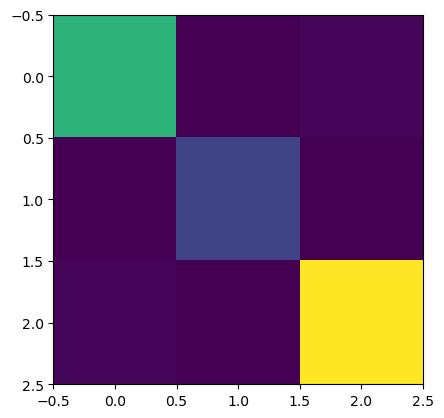

In [39]:
plt.imshow(F.cpu().detach().numpy(), vmin=0)

In [40]:
torch.sqrt(torch.inverse(F))*(180/np.pi)

tensor([[4.7854, 0.5477,    nan],
        [0.5477, 8.4918, 0.3547],
        [   nan, 0.3547, 3.8504]], device='cuda:0', dtype=torch.float64)

# On ratiometric 

In [20]:
def fisher_ratiometric(M_matrix, RHO, ETA, DELTA, BACKGROUND):
    omega = 2*torch.pi*(1-torch.cos(DELTA))
    gamma = 1 - (3*omega)/(4*torch.pi) + omega**2/(8*torch.pi**2)
    
    dxx_eta = 2*gamma*(torch.cos(RHO)**2)*torch.sin(ETA)*torch.cos(ETA)
    dyy_eta = 2*gamma*(torch.sin(RHO)**2)*torch.sin(ETA)*torch.cos(ETA)
    dzz_eta = -2*gamma*torch.sin(ETA)*torch.cos(ETA)
    dxy_eta = 2*gamma*(torch.sin(RHO)*torch.cos(RHO))*torch.sin(ETA)*torch.cos(ETA)
    dxz_eta = gamma*torch.cos(RHO)*(torch.cos(ETA)**2-torch.sin(ETA)**2)
    dyz_eta = gamma*torch.sin(RHO)*(torch.cos(ETA)**2-torch.sin(ETA)**2)

    dxx_rho = -2*gamma*(torch.sin(ETA)**2)*torch.sin(RHO)*torch.cos(RHO)
    dyy_rho = 2*gamma*(torch.sin(ETA)**2)*torch.sin(RHO)*torch.cos(RHO)
    dzz_rho = 0*ETA
    dxy_rho = gamma*(torch.sin(ETA)**2)*(torch.cos(RHO)**2-torch.sin(RHO)**2)
    dxz_rho = -gamma*torch.cos(ETA)*torch.sin(ETA)*torch.sin(RHO)
    dyz_rho = gamma*torch.cos(ETA)*torch.sin(ETA)*torch.cos(RHO)

    dxx_gamma = (torch.sin(ETA)*torch.cos(RHO))**2 -1/3
    dyy_gamma = (torch.sin(ETA)*torch.sin(RHO))**2 -1/3
    dzz_gamma = (torch.cos(ETA))**2 -1/3
    dxy_gamma = (torch.sin(ETA)**2)*torch.cos(RHO)*torch.sin(RHO)
    dxz_gamma = torch.sin(ETA)*torch.cos(ETA)*torch.cos(RHO)
    dyz_gamma = torch.sin(ETA)*torch.cos(ETA)*torch.sin(RHO)

    Bxx = torch.real(torch.sum(M_matrix[:,:,:,0,0], dim=(-2,-1)))
    Byy = torch.real(torch.sum(M_matrix[:,:,:,1,1], dim=(-2,-1)))
    Bzz = torch.real(torch.sum(M_matrix[:,:,:,2,2], dim=(-2,-1)))
    Bxy = torch.real(torch.sum(M_matrix[:,:,:,0,1]+M_matrix[:,:,:,1,0], dim=(-2,-1)))
    Bxz = torch.real(torch.sum(M_matrix[:,:,:,0,2]+M_matrix[:,:,:,2,0], dim=(-2,-1)))
    Byz = torch.real(torch.sum(M_matrix[:,:,:,1,2]+M_matrix[:,:,:,2,1], dim=(-2,-1)))
    psf, norm = PSF(rho=RHO*180/torch.pi, eta=ETA*180/torch.pi, delta=DELTA*180/torch.pi, M=M_matrix, N_photons=N_photons, device=device, return_norm=True)
    NN = psf.shape[3]
    psf = torch.sum(((psf[:,:,:,NN//2-7:NN//2+7,NN//2-7:NN//2+7]+BACKGROUND)), dim=(-2,-1))
    
    #psf = psf.detach()
    #norm=norm.detach()
    Bxx, Byy, Bzz, Bxy, Bxz, Byz = torch.einsum('apb,a->apb', Bxx, (N_photons/norm)), torch.einsum('apb,a->apb', Byy, (N_photons/norm)), torch.einsum('apb,a->apb', Bzz, (N_photons/norm)), torch.einsum('apb,a->apb', Bxy, (N_photons/norm)), torch.einsum('apb,a->apb', Bxz, (N_photons/norm)), torch.einsum('apb,a->apb', Byz, (N_photons/norm))
    
    CR = torch.stack([torch.einsum('apb,a->apb', Bxx[:,:,:], dxx_rho) + 
                      torch.einsum('apb,a->apb', Byy[:,:,:], dyy_rho) + 
                      torch.einsum('apb,a->apb', Bzz[:,:,:], dzz_rho) + 
                      torch.einsum('apb,a->apb', Bxy[:,:,:], dxy_rho) + 
                      torch.einsum('apb,a->apb', Bxz[:,:,:], dxz_rho) + 
                      torch.einsum('apb,a->apb', Byz[:,:,:], dyz_rho), 
                      torch.einsum('apb,a->apb', Bxx[:,:,:], dxx_eta) + 
                      torch.einsum('apb,a->apb', Byy[:,:,:], dyy_eta) + 
                      torch.einsum('apb,a->apb', Bzz[:,:,:], dzz_eta) + 
                      torch.einsum('apb,a->apb', Bxy[:,:,:], dxy_eta) + 
                      torch.einsum('apb,a->apb', Bxz[:,:,:], dxz_eta) + 
                      torch.einsum('apb,a->apb', Byz[:,:,:], dyz_eta), 
                      torch.einsum('a,apb->apb', ((omega/(4*torch.pi**2))-3/(4*torch.pi))*(2*torch.pi*torch.sin(DELTA)), 
                                   torch.einsum('apb,a->apb', Bxx[:,:,:], dxx_gamma) + 
                                   torch.einsum('apb,a->apb', Byy[:,:,:], dyy_gamma) + 
                                   torch.einsum('apb,a->apb', Bzz[:,:,:], dzz_gamma) + 
                                   torch.einsum('apb,a->apb', Bxy[:,:,:], dxy_gamma) + 
                                   torch.einsum('apb,a->apb', Bxz[:,:,:], dxz_gamma) + 
                                   torch.einsum('apb,a->apb', Byz[:,:,:], dyz_gamma))])
    to_return = torch.sum(torch.einsum('uvapb, apb -> uvapb', torch.einsum('uapb, vapb -> uvapb', CR, CR), 1/psf), dim=(3,4))
    return to_return #torch.sqrt(to_return.real**2+to_return.imag**2+1e-12)  

In [31]:
F = fisher_ratiometric(M, torch.tensor(np.random.rand(NPSF)*np.pi, device=device), 
                        torch.tensor(np.arccos(np.random.uniform(-np.cos(75*np.pi/180), np.cos(75*np.pi/180), NPSF)), device=device),
                                     torch.tensor(np.pi/4+np.random.rand(NPSF)*np.pi/2, device=device), 
                                                  torch.tensor(10., device=device))

In [32]:
F = torch.mean(F, dim=2)

In [33]:
F

tensor([[189.6480,   0.2787,   2.0882],
        [  0.2787,   5.1792,  -0.7320],
        [  2.0882,  -0.7320, 263.6153]], device='cuda:0', dtype=torch.float64)

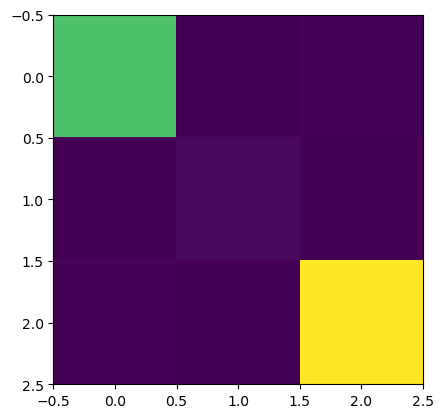

In [34]:
plt.imshow(F.cpu().detach().numpy(), vmin=0)

In [35]:
torch.sqrt(torch.inverse(F))*(180/np.pi)

tensor([[ 4.1609,     nan,     nan],
        [    nan, 25.1823,  1.3298],
        [    nan,  1.3298,  3.5297]], device='cuda:0', dtype=torch.float64)